In [56]:
%load_ext autoreload
%autoreload 2

import numpy as np
import networkx as nx
import torch

import sys
sys.path.append('../')
from proof_of_concept.models.staged import STAGED
from proof_of_concept.utils.graph_constructor import GraphConstructor
from proof_of_concept.utils.simulated_data_processing import retrieve_simulated_data,retrieve_real_data

from proof_of_concept.tests.test_graph_constructor import create_square_grid_data as create_test_data
from proof_of_concept.utils.visualization import visualize_attention_graph, visualize_graph

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [57]:
!pwd

/Users/joaofelipe/Yale/STAGED/4_Code/staged/notebooks


In [58]:
# data = retrieve_simulated_data(data_dir='../data/raw',sim_file='100_simulation_results.pkl')

In [45]:
from proof_of_concept.utils.data_factory import create_oscillatory_dynamics_data

# data = create_oscillatory_dynamics_data()
# for key, value in data.items():
#     if isinstance(value, (torch.Tensor, np.ndarray)):
#         print(f"{key}: {value.shape}")
#     elif isinstance(value, (list, dict)):
#         print(f"{key}: length {len(value)}")
#     else:
#         print(f"{key}: {value}")
data = retrieve_real_data(data_dir='../data/real')

In [46]:
for key, value in data.items():
    if isinstance(value, (torch.Tensor, np.ndarray)):
        print(f"{key}: {value.shape}")
    elif isinstance(value, (list, dict)):
        print(f"{key}: length {len(value)}")
    else:
        print(f"{key}: {value}")

gene_expression: torch.Size([10, 100, 428])
cell_positions: torch.Size([10, 100, 2])
genes: length 428
cell_type_assignments: torch.Size([100])
prior_grns: length 8
receptor_gene_pairs: length 3
ligand_receptor_pairs: length 3
n_time_points: 10
n_cells: 100
n_genes: 428


In [48]:
import os
import pickle

# Load config for future model use
config_path = os.path.join('../results', "config.pkl")
with open(config_path, "rb") as handle:
    config = pickle.load(handle)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = STAGED(
    num_genes=len(data['genes']),
    hidden_dim=config['model_config'].hidden_dim,
    num_gat_layers=config['model_config'].num_gat_layers,
    num_mlp_layers=config['model_config'].num_mlp_layers,
    dropout=config['model_config'].dropout,
    delta_gl=config['model_config'].delta_gl,
    delta_lr=config['model_config'].delta_lr,
    delta_rg=config['model_config'].delta_rg,
    delta_gg=config['model_config'].delta_gg,
    add_self_loops=config['model_config'].add_self_loops,
).to(device)
import os
import pickle

# Load results object from output directory
model_path = os.path.join('../results/real/ode/euler', "model.pt")
model.load_state_dict(torch.load(model_path))
model

/var/folders/1r/l8_zwkvx7_g7b632hf_1517c0000gn/T/ipykernel_78713/370593563.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))

STAGED(
  (gat_layers): ModuleList(
    (0): GATConv(1, 64, heads=1)
  )
  (mlp): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [49]:
data['genes']

['SPSB1',
 'MARCKSL1',
 'DAB1',
 'PDE4B',
 'SLC44A5',
 'ADGRL2',
 'TXNIP',
 'KCNN3',
 'ADAMTS4',
 'HSPA6',
 'MPZL1',
 'PAPPA2',
 'CACNA1E',
 'HMCN1',
 'CR1',
 'LINC00467',
 'PROX1-AS1',
 'SMYD2',
 'TGFB2',
 'DNAH14',
 'CHRM3',
 'PTRHD1',
 'TOGARAM2',
 'RMDN2',
 'RMDN2-AS1',
 'MAP4K3-DT',
 'SLC8A1-AS1',
 'ZFP36L2',
 'NRXN1',
 'EML6',
 'LINC01793',
 'WDPCP',
 'SERTAD2',
 'ANTXR1',
 'TACR1',
 'CTNNA2',
 'DNAH6',
 'AFF3',
 'CNTNAP5',
 'BIN1',
 'NCKAP5',
 'NCKAP5-AS1',
 'NCKAP5-AS2',
 'TMEM163',
 'CCNT2-AS1',
 'GALNT13',
 'RBMS1',
 'DPP4',
 'STK39',
 'MAP3K20',
 'OSBPL6',
 'SESTD1',
 'ZNF804A',
 'FSIP2-AS1',
 'FSIP2',
 'CALCRL',
 'PLCL1',
 'ICA1L',
 'ERBB4',
 'MOGAT1',
 'COL4A4',
 'PID1',
 'AGAP1',
 'GHRL',
 'NEK10',
 'RBMS3',
 'RBMS3-AS2',
 'CX3CR1',
 'MOBP',
 'CDCP1',
 'PFKFB4',
 'BSN',
 'DOCK3',
 'CACNA2D3',
 'ERC2',
 'HESX1',
 'PTPRG',
 'SYNPR',
 'ADAMTS9-AS2',
 'LMOD3',
 'ROBO1',
 'LINC02008',
 'CADM2',
 'ABI3BP',
 'ALCAM',
 'LSAMP',
 'EPHB1',
 'PPP2R3A',
 'MED12L',
 'MECOM',
 'NAALADL

In [50]:
data['ligand_receptor_pairs']

[('APP', 'PLXNA4'), ('TENM4', 'ADGRL2'), ('MPZL1', 'MPZL1')]

In [51]:
data['cell_type_assignments']

tensor([0, 7, 1, 2, 5, 5, 1, 5, 5, 5, 7, 5, 0, 0, 0, 2, 7, 1, 1, 6, 0, 0, 0, 1,
        0, 0, 2, 0, 0, 1, 6, 7, 2, 1, 0, 1, 0, 2, 4, 0, 0, 0, 0, 1, 0, 0, 0, 0,
        3, 7, 0, 7, 6, 3, 0, 0, 1, 0, 3, 0, 0, 5, 6, 0, 1, 7, 0, 3, 0, 7, 7, 0,
        0, 7, 0, 3, 0, 6, 1, 1, 7, 4, 1, 5, 0, 1, 3, 0, 1, 3, 5, 0, 5, 6, 0, 0,
        7, 1, 0, 0])

In [52]:
graph_constructor = GraphConstructor(
    genes=data['genes'],
    ligand_receptor_pairs=data['ligand_receptor_pairs'],
    receptor_gene_pairs=data['receptor_gene_pairs'],
    cell_type_assignments=data['cell_type_assignments'],
    prior_grns=data['prior_grns']
)

# Define time lags as specified by the user
delta_gl = 1  # Time lag for gene -> ligand
delta_lr = 2  # Time lag for ligand -> receptor
delta_rg = 1  # Time lag for receptor -> gene
delta_gg = 0  # Time lag for gene -> gene

time_point = 8
cell_idx = 1

# Ensure time_point is large enough to handle the lags
max_lag = max(delta_gl, delta_lr, delta_rg, delta_gg)
if time_point < max_lag:
    time_point = max_lag
    print(f"Adjusted time_point to {time_point} to handle time lags")


/Users/joaofelipe/Yale/STAGED/4_Code/staged/proof_of_concept/utils/visualization.py:98: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/joaofelipe/miniconda3/envs/staged/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


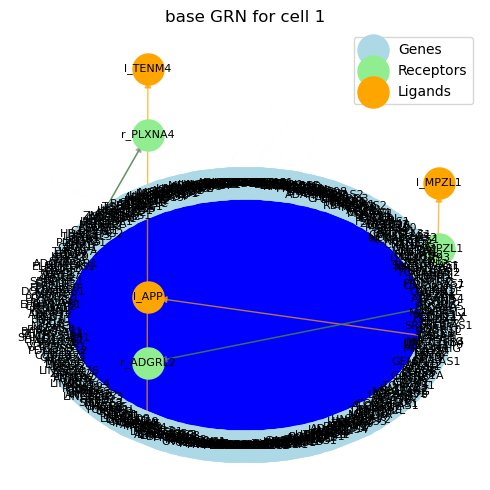

In [53]:

base_graph = graph_constructor.construct_base_graph(cell_idx)
visualize_graph(base_graph, f"base GRN for cell {cell_idx}", save_plot=False, show_plot=True, figsize=(5, 5))

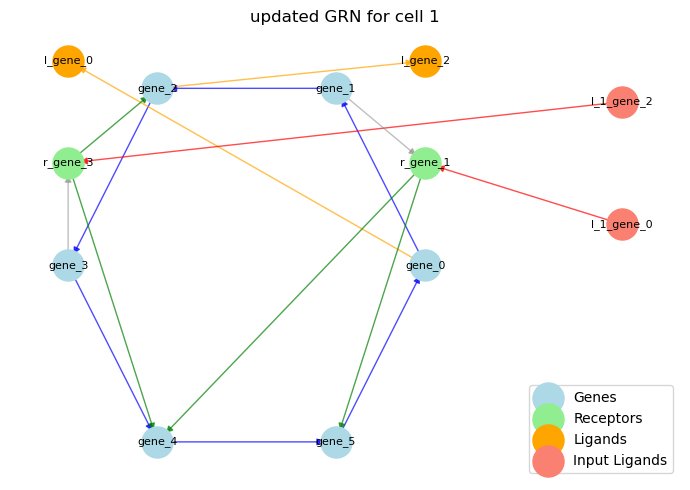

In [30]:
distance_threshold = 1
updated_graph = graph_constructor.update_graph_with_neighbors(
    base_graph, cell_idx, data['cell_positions'], time_point,
    distance_threshold=distance_threshold
)
pos = visualize_graph(updated_graph, f"updated GRN for cell {cell_idx}", save_plot=False, show_plot=True, figsize=(7, 5), return_pos=True)


In [31]:
import matplotlib.pyplot as plt
def visualize_attention_graph(pyg_graph, edge_index, attention_weights, pos, figsize=(12, 10), show_labels=True):
    """
    Visualize a graph with attention weights and node types.
    
    Args:
        pyg_graph: PyTorch Geometric graph object containing node names and types
        edge_index: Tensor containing edge indices
        attention_weights: Tensor containing attention weights
            from `node_embeddings, (edge_index, attention_weights) = model(pyg_graph)`
        pos: Dictionary mapping node names to positions
        figsize: Tuple specifying figure size
        show_labels: Whether to show node labels (default: True)
        
    Returns:
        None. Displays the graph visualization.
    """
    # Create a NetworkX graph from edge_index with node names
    G = nx.DiGraph()
    node_names = pyg_graph.node_names
    edge_list = [(node_names[src], node_names[dst]) for src, dst in edge_index.t().tolist()]
    G.add_edges_from(edge_list)

    # Create mapping from node names to their types
    node_name_to_type = {name: type_ for name, type_ in zip(pyg_graph.node_names, pyg_graph.node_types)}

    # Compute average attention weights across heads for visualization
    avg_attention = attention_weights.mean(dim=1).detach().numpy()

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Create color map for node types
    node_type_colors = {
        'gene': 'lightblue',
        'receptor': 'lightgreen', 
        'ligand': 'orange',
        'input_ligand': 'salmon'
    }

    # Get node colors based on type, using the NetworkX graph node order
    node_colors = [node_type_colors[node_name_to_type[node]] for node in G.nodes()]

    # Draw graph with attention weights as edge colors and labels
    nx.draw(G, pos, ax=ax, with_labels=show_labels, node_color=node_colors,
            edge_color=avg_attention, edge_cmap=plt.cm.Blues, width=2,
            labels={node: node for node in G.nodes()} if show_labels else {})

    # Add edge labels showing attention weights
    # Create edge labels dictionary including self-loops
    edge_labels = {}
    for (src, dst), att in zip(edge_index.t().tolist(), avg_attention):
        src_name = node_names[src]
        dst_name = node_names[dst]
        edge_labels[(src_name, dst_name)] = f'{att:.2f}'
        # For self-loops, adjust position slightly to make label visible
        if src == dst:
            pos_adj = {node: (x + 0.1, y + 0.1) for node, (x, y) in pos.items()}
            nx.draw_networkx_edge_labels(G, pos_adj, edge_labels={(src_name, dst_name): edge_labels[(src_name, dst_name)]}, ax=ax)
    
    # Draw labels for non-self-loop edges
    non_self_loops = {(s, d): l for (s, d), l in edge_labels.items() if s != d}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=non_self_loops, ax=ax)

    # Add colorbar for attention weights
    sm = plt.cm.ScalarMappable(cmap=plt.cm.Blues,
                              norm=plt.Normalize(vmin=avg_attention.min(),
                                               vmax=avg_attention.max()))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Average Attention Weight')

    # Add legend for node types
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                                markerfacecolor=color, label=node_type, markersize=10)
                      for node_type, color in node_type_colors.items()]
    ax.legend(handles=legend_elements, loc='lower right', title='Node Types')

    ax2 = ax.twinx()
    ax2.set_yticks([])

    ax.set_title('Graph with Attention Weights and Values')

    plt.tight_layout()
    plt.show()

In [32]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def visualize_gene_attention(pyg_graph, edge_index, attention_weights, pos, target_gene, 
                           figsize=(12, 10), show_labels=True, highlight_mode='both'):
    """
    Visualize a graph with attention weights focused on a specific gene.
    
    Args:
        pyg_graph: PyTorch Geometric graph object containing node names and types
        edge_index: Tensor containing edge indices
        attention_weights: Tensor containing attention weights
            from `node_embeddings, (edge_index, attention_weights) = model(pyg_graph)`
        pos: Dictionary mapping node names to positions
        target_gene: Name of the gene to focus on
        figsize: Tuple specifying figure size
        show_labels: Whether to show node labels (default: True)
        highlight_mode: 'incoming', 'outgoing', or 'both' (default: 'both')
        
    Returns:
        None. Displays the graph visualization.
    """
    # Create a NetworkX graph from edge_index with node names
    G = nx.DiGraph()
    node_names = pyg_graph.node_names
    edge_list = [(node_names[src], node_names[dst]) for src, dst in edge_index.t().tolist()]
    G.add_edges_from(edge_list)

    # Check if target gene exists
    if target_gene not in node_names:
        print(f"Warning: Gene '{target_gene}' not found in the graph.")
        print(f"Available genes: {[name for name, type_ in zip(node_names, pyg_graph.node_types) if type_ == 'gene']}")
        return

    # Create mapping from node names to their types
    node_name_to_type = {name: type_ for name, type_ in zip(pyg_graph.node_names, pyg_graph.node_types)}

    # Compute average attention weights across heads for visualization
    avg_attention = attention_weights.mean(dim=1).detach().numpy()

    # Find edges related to target gene
    target_edges = []
    target_attention_weights = []
    other_edges = []
    other_attention_weights = []
    
    for i, (src, dst) in enumerate(edge_index.t().tolist()):
        src_name = node_names[src]
        dst_name = node_names[dst]
        
        is_target_edge = False
        if highlight_mode == 'incoming' and dst_name == target_gene:
            is_target_edge = True
        elif highlight_mode == 'outgoing' and src_name == target_gene:
            is_target_edge = True
        elif highlight_mode == 'both' and (src_name == target_gene or dst_name == target_gene):
            is_target_edge = True
            
        if is_target_edge:
            target_edges.append((src_name, dst_name))
            target_attention_weights.append(avg_attention[i])
        else:
            other_edges.append((src_name, dst_name))
            other_attention_weights.append(avg_attention[i])

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Create color map for node types
    node_type_colors = {
        'gene': 'lightblue',
        'receptor': 'lightgreen', 
        'ligand': 'orange',
        'input_ligand': 'salmon'
    }

    # Get node colors, highlighting target gene
    node_colors = []
    for node in G.nodes():
        if node == target_gene:
            node_colors.append('red')  # Highlight target gene in red
        else:
            node_colors.append(node_type_colors[node_name_to_type[node]])

    # Draw all nodes
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=300)
    
    # Draw non-target edges with low opacity
    if other_edges:
        other_G = nx.DiGraph()
        other_G.add_edges_from(other_edges)
        nx.draw_networkx_edges(other_G, pos, ax=ax, edge_color='lightgray', 
                              width=0.5, alpha=0.3, arrows=True, arrowsize=10)
    
    # Draw target edges with attention-based coloring
    if target_edges:
        target_G = nx.DiGraph()
        target_G.add_edges_from(target_edges)
        
        # Normalize attention weights for better visualization
        if len(target_attention_weights) > 1:
            norm_weights = np.array(target_attention_weights)
            norm_weights = (norm_weights - norm_weights.min()) / (norm_weights.max() - norm_weights.min() + 1e-8)
        else:
            norm_weights = target_attention_weights
            
        nx.draw_networkx_edges(target_G, pos, ax=ax, edge_color=target_attention_weights,
                              edge_cmap=plt.cm.Reds, width=3, arrows=True, arrowsize=15)

    # Add node labels if requested
    if show_labels:
        nx.draw_networkx_labels(G, pos, ax=ax)

    # Add edge labels for target edges only
    target_edge_labels = {}
    for edge, att in zip(target_edges, target_attention_weights):
        target_edge_labels[edge] = f'{att:.3f}'
    
    if target_edge_labels:
        nx.draw_networkx_edge_labels(G, pos, edge_labels=target_edge_labels, 
                                    ax=ax, font_size=8, bbox=dict(boxstyle='round,pad=0.2', 
                                    facecolor='white', alpha=0.8))

    # Add colorbar for target attention weights
    if target_attention_weights:
        sm = plt.cm.ScalarMappable(cmap=plt.cm.Reds,
                                  norm=plt.Normalize(vmin=min(target_attention_weights),
                                                   vmax=max(target_attention_weights)))
        sm.set_array([])
        plt.colorbar(sm, ax=ax, label=f'Attention Weight for {target_gene}')

    # Add legend for node types (including highlighted target)
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                                markerfacecolor=color, label=node_type, markersize=10)
                      for node_type, color in node_type_colors.items()]
    legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                    markerfacecolor='red', label=f'Target: {target_gene}', markersize=10))
    ax.legend(handles=legend_elements, loc='lower right', title='Node Types')

    # Set title based on highlight mode
    mode_text = {
        'incoming': f'Incoming connections to {target_gene}',
        'outgoing': f'Outgoing connections from {target_gene}',
        'both': f'All connections for {target_gene}'
    }
    
    ax.set_title(f'Gene Attention Visualization: {mode_text[highlight_mode]}')
    
    # Print summary statistics
    if target_attention_weights:
        print(f"\nAttention Statistics for {target_gene}:")
        print(f"Number of highlighted edges: {len(target_attention_weights)}")
        print(f"Average attention weight: {np.mean(target_attention_weights):.4f}")
        print(f"Max attention weight: {np.max(target_attention_weights):.4f}")
        print(f"Min attention weight: {np.min(target_attention_weights):.4f}")
        
        # Show top connections
        if len(target_edges) > 0:
            sorted_connections = sorted(zip(target_edges, target_attention_weights), 
                                      key=lambda x: x[1], reverse=True)
            print(f"\nTop connections (by attention weight):")
            for i, ((src, dst), weight) in enumerate(sorted_connections[:5]):
                direction = f"{src} → {dst}" if src != target_gene else f"{dst} → {src}"
                print(f"  {i+1}. {direction}: {weight:.4f}")

    plt.tight_layout()
    plt.show()


In [33]:
pyg_graph = graph_constructor.assign_node_features(
    updated_graph, cell_idx, time_point, data['gene_expression'],
    delta_gl, delta_lr, delta_rg, delta_gg
)

In [34]:
node_embeddings, (edge_index, attention_weights) = model(pyg_graph)

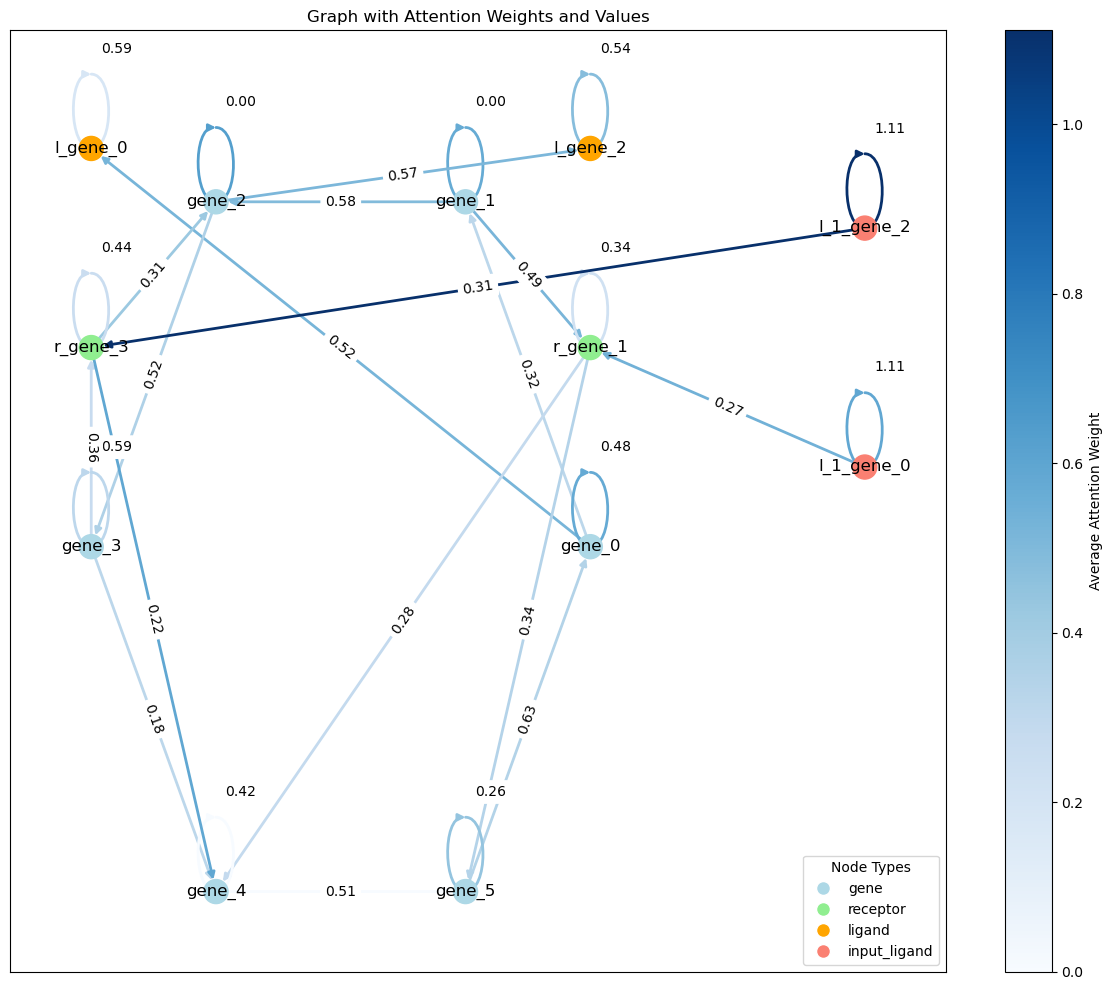

In [35]:
visualize_attention_graph(pyg_graph, edge_index, attention_weights, pos, figsize=(12, 10))

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def visualize_single_gene_attention(pyg_graph, edge_index, attention_weights, pos, target_gene, 
                           figsize=(12, 10), show_labels=True, highlight_mode='both'):
    """
    Visualize a graph with attention weights focused on a specific gene.
    
    Args:
        pyg_graph: PyTorch Geometric graph object containing node names and types
        edge_index: Tensor containing edge indices
        attention_weights: Tensor containing attention weights
            from `node_embeddings, (edge_index, attention_weights) = model(pyg_graph)`
        pos: Dictionary mapping node names to positions
        target_gene: Name of the gene to focus on
        figsize: Tuple specifying figure size
        show_labels: Whether to show node labels (default: True)
        highlight_mode: 'incoming', 'outgoing', or 'both' (default: 'both')
        
    Returns:
        None. Displays the graph visualization.
    """
    # Create a NetworkX graph from edge_index with node names
    G = nx.DiGraph()
    node_names = pyg_graph.node_names
    edge_list = [(node_names[src], node_names[dst]) for src, dst in edge_index.t().tolist()]
    G.add_edges_from(edge_list)

    # Check if target gene exists
    if target_gene not in node_names:
        print(f"Warning: Gene '{target_gene}' not found in the graph.")
        print(f"Available genes: {[name for name, type_ in zip(node_names, pyg_graph.node_types) if type_ == 'gene']}")
        return

    # Create mapping from node names to their types
    node_name_to_type = {name: type_ for name, type_ in zip(pyg_graph.node_names, pyg_graph.node_types)}

    # Compute average attention weights across heads for visualization
    avg_attention = attention_weights.mean(dim=1).detach().numpy()

    # Find edges related to target gene
    target_edges = []
    target_attention_weights = []
    other_edges = []
    other_attention_weights = []
    
    for i, (src, dst) in enumerate(edge_index.t().tolist()):
        src_name = node_names[src]
        dst_name = node_names[dst]
        
        is_target_edge = False
        if highlight_mode == 'incoming' and dst_name == target_gene:
            is_target_edge = True
        elif highlight_mode == 'outgoing' and src_name == target_gene:
            is_target_edge = True
        elif highlight_mode == 'both' and (src_name == target_gene or dst_name == target_gene):
            is_target_edge = True
            
        if is_target_edge:
            target_edges.append((src_name, dst_name))
            target_attention_weights.append(avg_attention[i])
        else:
            other_edges.append((src_name, dst_name))
            other_attention_weights.append(avg_attention[i])

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Create color map for node types
    node_type_colors = {
        'gene': 'lightblue',
        'receptor': 'lightgreen', 
        'ligand': 'orange',
        'input_ligand': 'salmon'
    }

    # Get node colors, highlighting target gene
    node_colors = []
    for node in G.nodes():
        if node == target_gene:
            node_colors.append('red')  # Highlight target gene in red
        else:
            node_colors.append(node_type_colors[node_name_to_type[node]])

    # Draw all nodes
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=300)
    
    # Draw non-target edges with low opacity
    if other_edges:
        other_G = nx.DiGraph()
        other_G.add_edges_from(other_edges)
        nx.draw_networkx_edges(other_G, pos, ax=ax, edge_color='lightgray', 
                              width=0.5, alpha=0.3, arrows=True, arrowsize=10)
    
    # Draw target edges with attention-based coloring
    if target_edges:
        target_G = nx.DiGraph()
        target_G.add_edges_from(target_edges)
        
        # Normalize attention weights for better visualization
        if len(target_attention_weights) > 1:
            norm_weights = np.array(target_attention_weights)
            norm_weights = (norm_weights - norm_weights.min()) / (norm_weights.max() - norm_weights.min() + 1e-8)
        else:
            norm_weights = target_attention_weights
            
        nx.draw_networkx_edges(target_G, pos, ax=ax, edge_color=target_attention_weights,
                              edge_cmap=plt.cm.Reds, width=3, arrows=True, arrowsize=15)

    # Add node labels if requested
    if show_labels:
        nx.draw_networkx_labels(G, pos, ax=ax)

    # Add edge labels for target edges only
    target_edge_labels = {}
    for edge, att in zip(target_edges, target_attention_weights):
        target_edge_labels[edge] = f'{att:.3f}'
    
    if target_edge_labels:
        nx.draw_networkx_edge_labels(G, pos, edge_labels=target_edge_labels, 
                                    ax=ax, font_size=8, bbox=dict(boxstyle='round,pad=0.2', 
                                    facecolor='white', alpha=0.8))

    # Add colorbar for target attention weights
    if target_attention_weights:
        sm = plt.cm.ScalarMappable(cmap=plt.cm.Reds,
                                  norm=plt.Normalize(vmin=min(target_attention_weights),
                                                   vmax=max(target_attention_weights)))
        sm.set_array([])
        plt.colorbar(sm, ax=ax, label=f'Attention Weight for {target_gene}')

    # Add legend for node types (including highlighted target)
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                                markerfacecolor=color, label=node_type, markersize=10)
                      for node_type, color in node_type_colors.items()]
    legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                    markerfacecolor='red', label=f'Target: {target_gene}', markersize=10))
    ax.legend(handles=legend_elements, loc='lower right', title='Node Types')

    # Set title based on highlight mode
    mode_text = {
        'incoming': f'Incoming connections to {target_gene}',
        'outgoing': f'Outgoing connections from {target_gene}',
        'both': f'All connections for {target_gene}'
    }
    
    ax.set_title(f'Gene Attention Visualization: {mode_text[highlight_mode]}')
    
    # Print summary statistics
    if target_attention_weights:
        print(f"\nAttention Statistics for {target_gene}:")
        print(f"Number of highlighted edges: {len(target_attention_weights)}")
        print(f"Average attention weight: {np.mean(target_attention_weights):.4f}")
        print(f"Max attention weight: {np.max(target_attention_weights):.4f}")
        print(f"Min attention weight: {np.min(target_attention_weights):.4f}")
        
        # Show top connections
        if len(target_edges) > 0:
            sorted_connections = sorted(zip(target_edges, target_attention_weights), 
                                      key=lambda x: x[1], reverse=True)
            print(f"\nTop connections (by attention weight):")
            for i, ((src, dst), weight) in enumerate(sorted_connections[:5]):
                direction = f"{src} → {dst}" if src != target_gene else f"{dst} → {src}"
                print(f"  {i+1}. {direction}: {weight:.4f}")

    plt.tight_layout()
    plt.show()



Attention Statistics for gene_1:
Number of highlighted edges: 4
Average attention weight: 0.3462
Max attention weight: 0.5759
Min attention weight: 0.0000

Top connections (by attention weight):
  1. gene_2 → gene_1: 0.5759
  2. r_gene_1 → gene_1: 0.4929
  3. gene_0 → gene_1: 0.3163
  4. gene_1 → gene_1: 0.0000


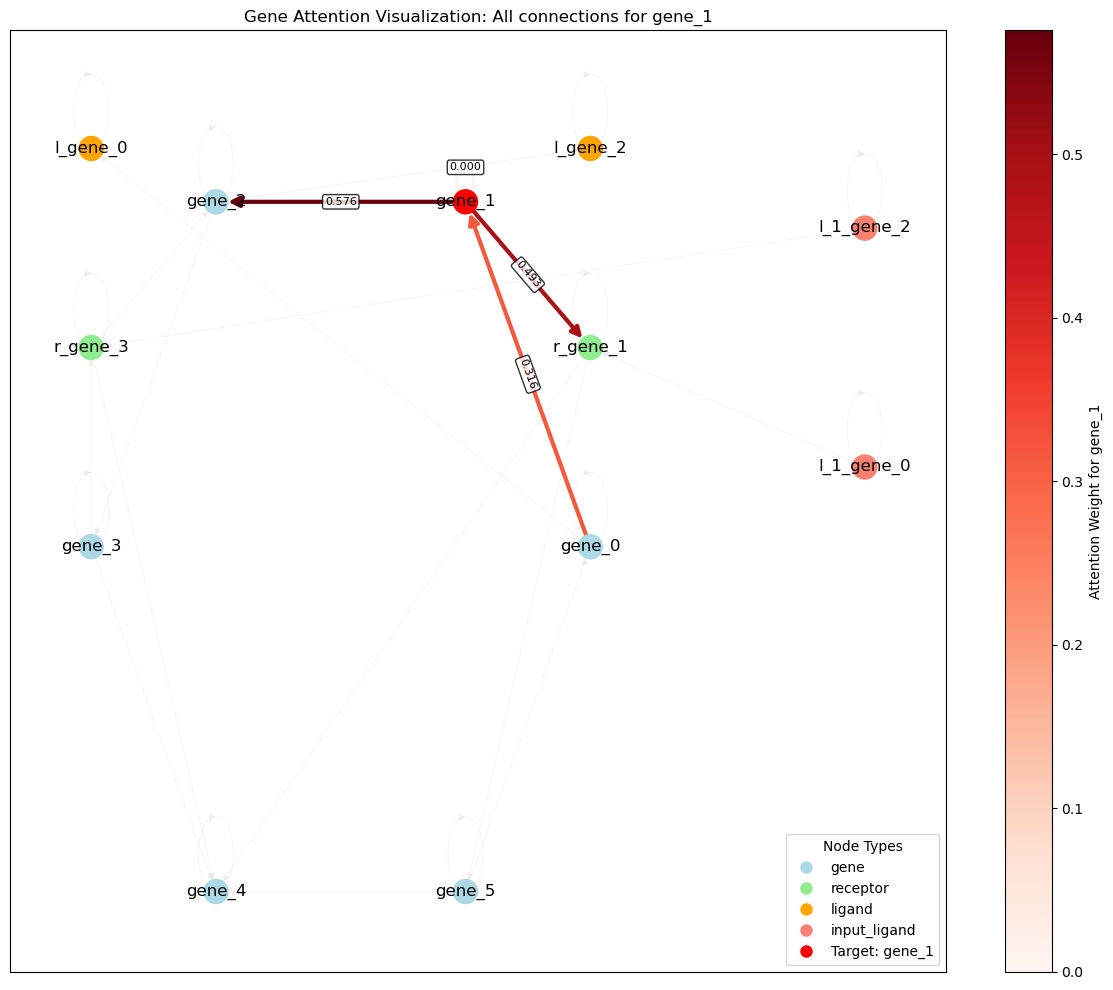

In [36]:
visualize_gene_attention(pyg_graph, edge_index, attention_weights, pos, target_gene='gene_1', figsize=(12, 10))

In [54]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def visualize_single_gene_attention(pyg_graph, edge_index, attention_weights, pos, target_gene, 
                           figsize=(12, 10), show_labels=True, highlight_mode='both', top_k=10):
    """
    Visualize a graph with attention weights focused on a specific gene and its most attended connections.
    
    Args:
        pyg_graph: PyTorch Geometric graph object containing node names and types
        edge_index: Tensor containing edge indices
        attention_weights: Tensor containing attention weights
            from `node_embeddings, (edge_index, attention_weights) = model(pyg_graph)`
        pos: Dictionary mapping node names to positions
        target_gene: Name of the gene to focus on
        figsize: Tuple specifying figure size
        show_labels: Whether to show node labels (default: True)
        highlight_mode: 'incoming', 'outgoing', or 'both' (default: 'both')
        top_k: Number of top attention connections to display (default: 10)
        
    Returns:
        None. Displays the graph visualization.
    """
    # Create node names mapping
    node_names = pyg_graph.node_names

    # Check if target gene exists
    if target_gene not in node_names:
        print(f"Warning: Gene '{target_gene}' not found in the graph.")
        print(f"Available genes: {[name for name, type_ in zip(node_names, pyg_graph.node_types) if type_ == 'gene']}")
        return

    # Create mapping from node names to their types
    node_name_to_type = {name: type_ for name, type_ in zip(pyg_graph.node_names, pyg_graph.node_types)}

    # Compute average attention weights across heads for visualization
    avg_attention = attention_weights.mean(dim=1).detach().numpy()

    # Find edges related to target gene and their attention weights
    target_connections = []
    
    for i, (src, dst) in enumerate(edge_index.t().tolist()):
        src_name = node_names[src]
        dst_name = node_names[dst]
        
        is_target_edge = False
        if highlight_mode == 'incoming' and dst_name == target_gene:
            is_target_edge = True
        elif highlight_mode == 'outgoing' and src_name == target_gene:
            is_target_edge = True
        elif highlight_mode == 'both' and (src_name == target_gene or dst_name == target_gene):
            is_target_edge = True
            
        if is_target_edge:
            target_connections.append((src_name, dst_name, avg_attention[i]))

    if not target_connections:
        print(f"No connections found for {target_gene} in {highlight_mode} mode.")
        return

    # Sort by attention weight and take top_k connections
    target_connections.sort(key=lambda x: x[2], reverse=True)
    top_connections = target_connections[:top_k]

    # Extract nodes involved in top connections
    nodes_to_plot = {target_gene}
    edges_to_plot = []
    attention_values = []
    
    for src, dst, att in top_connections:
        nodes_to_plot.add(src)
        nodes_to_plot.add(dst)
        edges_to_plot.append((src, dst))
        attention_values.append(att)

    # Create a focused NetworkX graph with only relevant nodes and edges
    G = nx.DiGraph()
    G.add_nodes_from(nodes_to_plot)
    G.add_edges_from(edges_to_plot)

    # Filter positions to only include nodes we're plotting
    filtered_pos = {node: pos[node] for node in nodes_to_plot if node in pos}
    
    # If some nodes don't have positions, create a layout for the subgraph
    if len(filtered_pos) < len(nodes_to_plot):
        missing_nodes = nodes_to_plot - set(filtered_pos.keys())
        print(f"Warning: Position not found for nodes: {missing_nodes}")
        # Use spring layout for the focused subgraph
        filtered_pos = nx.spring_layout(G, pos=filtered_pos, fixed=list(filtered_pos.keys()))

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Create color map for node types
    node_type_colors = {
        'gene': 'lightblue',
        'receptor': 'lightgreen', 
        'ligand': 'orange',
        'input_ligand': 'salmon'
    }

    # Get node colors, highlighting target gene
    node_colors = []
    node_sizes = []
    for node in G.nodes():
        if node == target_gene:
            node_colors.append('red')  # Highlight target gene in red
            node_sizes.append(500)  # Make target gene larger
        else:
            node_colors.append(node_type_colors.get(node_name_to_type[node], 'gray'))
            node_sizes.append(300)

    # Draw nodes
    nx.draw_networkx_nodes(G, filtered_pos, ax=ax, node_color=node_colors, node_size=node_sizes)
    
    # Draw edges with attention-based coloring and width
    if edges_to_plot:
        # Normalize attention weights for better visualization
        if len(attention_values) > 1:
            norm_weights = np.array(attention_values)
            min_att, max_att = norm_weights.min(), norm_weights.max()
            if max_att > min_att:
                norm_weights = (norm_weights - min_att) / (max_att - min_att)
            else:
                norm_weights = np.ones_like(norm_weights)
        else:
            norm_weights = np.array([1.0])
            
        # Scale edge widths based on attention (1-5 range)
        edge_widths = 1 + 4 * norm_weights
        
        nx.draw_networkx_edges(G, filtered_pos, ax=ax, edge_color=attention_values,
                              edge_cmap=plt.cm.Reds, width=edge_widths, arrows=True, 
                              arrowsize=20, connectionstyle="arc3,rad=0.1")

    # Add node labels if requested
    if show_labels:
        # Make target gene label bold
        label_dict = {}
        for node in G.nodes():
            if node == target_gene:
                label_dict[node] = f"**{node}**"
            else:
                label_dict[node] = node
        nx.draw_networkx_labels(G, filtered_pos, labels=label_dict, ax=ax, font_size=10, font_weight='bold')

    # Add edge labels for attention weights
    edge_labels = {}
    for (src, dst), att in zip(edges_to_plot, attention_values):
        edge_labels[(src, dst)] = f'{att:.3f}'
    
    nx.draw_networkx_edge_labels(G, filtered_pos, edge_labels=edge_labels, 
                                ax=ax, font_size=8, bbox=dict(boxstyle='round,pad=0.2', 
                                facecolor='white', alpha=0.8))

    # Add colorbar for attention weights
    if attention_values:
        sm = plt.cm.ScalarMappable(cmap=plt.cm.Reds,
                                  norm=plt.Normalize(vmin=min(attention_values),
                                                   vmax=max(attention_values)))
        sm.set_array([])
        plt.colorbar(sm, ax=ax, label=f'Attention Weight')

    # Add legend for node types (including highlighted target)
    legend_elements = []
    present_types = set(node_name_to_type[node] for node in nodes_to_plot if node != target_gene)
    
    for node_type in present_types:
        if node_type in node_type_colors:
            legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                            markerfacecolor=node_type_colors[node_type], 
                                            label=node_type, markersize=10))
    
    legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                    markerfacecolor='red', label=f'Target: {target_gene}', markersize=12))
    
    ax.legend(handles=legend_elements, loc='upper right', title='Node Types')

    # Set title based on highlight mode
    mode_text = {
        'incoming': f'Top {len(edges_to_plot)} incoming connections to {target_gene}',
        'outgoing': f'Top {len(edges_to_plot)} outgoing connections from {target_gene}',
        'both': f'Top {len(edges_to_plot)} connections for {target_gene}'
    }
    
    ax.set_title(f'Focused Gene Attention Visualization: {mode_text[highlight_mode]}', 
                 fontsize=14, fontweight='bold')
    
    # Remove axis for cleaner look
    ax.set_axis_off()
    
    # Print summary statistics
    print(f"\nFocused Attention Analysis for {target_gene}:")
    print(f"Showing top {len(edges_to_plot)} of {len(target_connections)} total connections")
    print(f"Nodes in visualization: {len(nodes_to_plot)}")
    print(f"Average attention weight (shown): {np.mean(attention_values):.4f}")
    print(f"Max attention weight (shown): {np.max(attention_values):.4f}")
    print(f"Min attention weight (shown): {np.min(attention_values):.4f}")
    
    # Show the connections with their weights
    print(f"\nTop {len(edges_to_plot)} connections (by attention weight):")
    for i, (src, dst, weight) in enumerate(top_connections):
        if src == target_gene:
            direction = f"{target_gene} → {dst}"
        else:
            direction = f"{src} → {target_gene}"
        print(f"  {i+1}. {direction}: {weight:.4f}")

    plt.tight_layout()
    plt.show()
    
    return G, filtered_pos, attention_values


Focused Attention Analysis for gene_1:
Showing top 4 of 4 total connections
Nodes in visualization: 4
Average attention weight (shown): 0.3462
Max attention weight (shown): 0.5759
Min attention weight (shown): 0.0000

Top 4 connections (by attention weight):
  1. gene_1 → gene_2: 0.5759
  2. gene_1 → r_gene_1: 0.4929
  3. gene_0 → gene_1: 0.3163
  4. gene_1 → gene_1: 0.0000


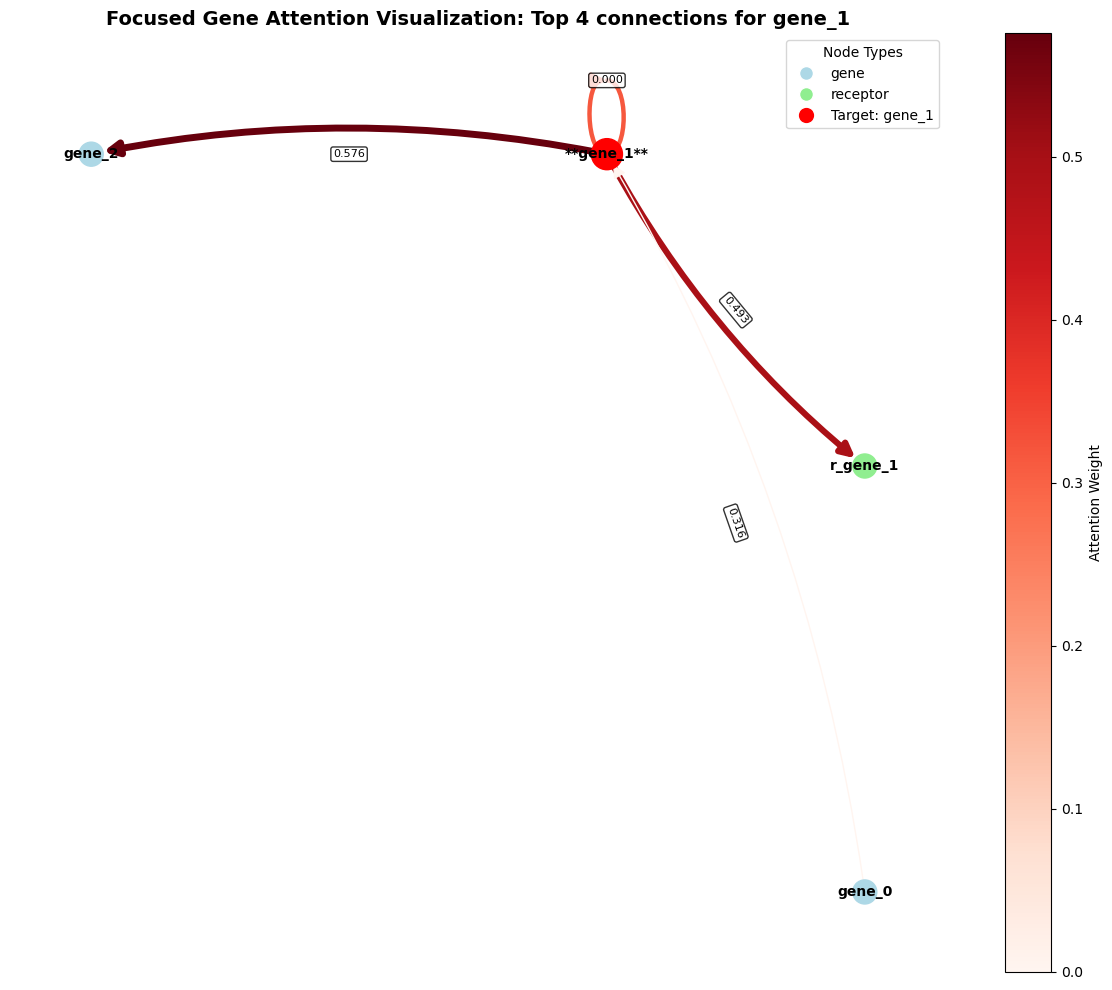

(<networkx.classes.digraph.DiGraph at 0x33d1a92a0>,
 {'gene_1': (np.float64(0.49999997764825854), np.float64(0.36602545944524423)),
  'gene_2': (np.float64(-0.5000000372529024), np.float64(0.36602539984060034)),
  'gene_0': (np.float64(1.0), np.float64(-0.4999999754954301)),
  'r_gene_1': (np.float64(1.0), np.float64(4.371138828673793e-08))},
 [np.float32(0.57585293),
  np.float32(0.49286768),
  np.float32(0.31626573),
  np.float32(0.0)])

In [55]:
visualize_single_gene_attention(pyg_graph, edge_index, attention_weights, pos, target_gene='gene_1', figsize=(12, 10))